# Preprocessing Data NO<sub>2</sub> Kabupaten Bangkalan

## **Penanganan Missing Values**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


**Penjelasan:**
- pandas: Library untuk manipulasi dan analisis data
- matplotlib.pyplot: Library untuk visualisasi data dan grafik

In [2]:
NO2 = pd.read_csv('no2_results/no2_bangkalan_data.csv')
NO2 = NO2.sort_values(by='date')
NO2

,date,feature_index,NO2
200,2024-12-31T00:00:00.000Z,0,NaN
197,2025-01-01T00:00:00.000Z,0,NaN
195,2025-01-02T00:00:00.000Z,0,NaN
198,2025-01-03T00:00:00.000Z,0,0.000040
194,2025-01-04T00:00:00.000Z,0,NaN
...,...,...,...
167,2025-09-26T00:00:00.000Z,0,0.000019
161,2025-09-27T00:00:00.000Z,0,0.000017
166,2025-09-28T00:00:00.000Z,0,0.000017
193,2025-09-29T00:00:00.000Z,0,0.000028


**Penjelasan:**
- Memuat dataset NO₂ dari file CSV hasil pengambilan data satelit
- Mengurutkan data berdasarkan tanggal untuk memastikan urutan temporal yang benar
- Menampilkan dataset untuk inspeksi awal

In [3]:
NO2.isnull().sum()

date               0
feature_index      0
NO2              102
dtype: int64

**Penjelasan:** Menghitung jumlah missing values pada setiap kolom untuk mengidentifikasi tingkat kelengkapan data.

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_20172\800750193.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


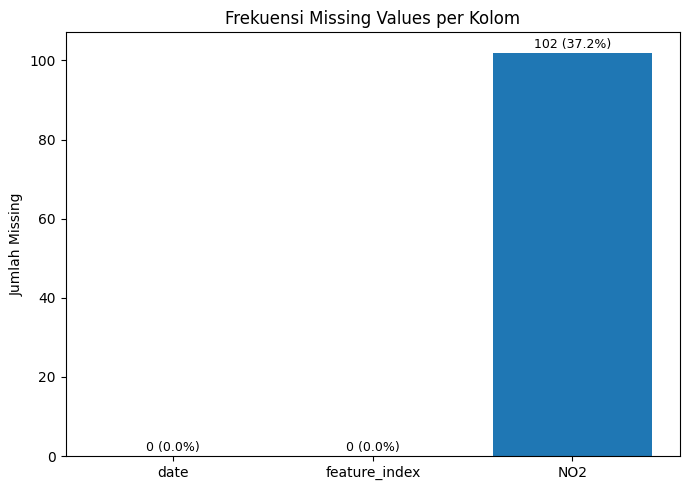

,Missing Count,Missing Percent (%)
date,0,0.00
feature_index,0,0.00
NO2,102,37.23


In [4]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

**Penjelasan:**
- Membuat visualisasi bar chart untuk missing values
- Menampilkan jumlah dan persentase missing values di atas setiap bar
- Membuat tabel summary missing values untuk dokumentasi

In [5]:
NO2 = pd.Series(NO2['NO2'].values, index=NO2['date'], name='NO2')
NO2 = NO2.interpolate(method='linear').bfill()
NO2 = pd.DataFrame(NO2).reset_index()
NO2

,date,NO2
0,2024-12-31T00:00:00.000Z,0.000040
1,2025-01-01T00:00:00.000Z,0.000040
2,2025-01-02T00:00:00.000Z,0.000040
3,2025-01-03T00:00:00.000Z,0.000040
4,2025-01-04T00:00:00.000Z,0.000038
...,...,...
269,2025-09-26T00:00:00.000Z,0.000019
270,2025-09-27T00:00:00.000Z,0.000017
271,2025-09-28T00:00:00.000Z,0.000017
272,2025-09-29T00:00:00.000Z,0.000028


**Penjelasan:**
- Konversi ke Series: Mengubah data menjadi pandas Series dengan index tanggal
- Linear Interpolation: Mengisi missing values dengan interpolasi linear berdasarkan nilai sebelum dan sesudahnya
- Backward Fill: Mengisi missing values yang tersisa dengan nilai valid berikutnya
- Konversi kembali: Mengubah kembali ke DataFrame dan reset index
- Metode ini mempertahankan pola temporal data

In [6]:
NO2.isnull().sum()

date    0
NO2     0
dtype: int64

**Penjelasan:** Memverifikasi bahwa semua missing values telah berhasil ditangani setelah proses interpolasi dan backward fill.

In [7]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

,Missing Count,Missing Percent (%)
date,0,0.0
NO2,0,0.0


**Penjelasan:** Membuat tabel summary untuk mendokumentasikan bahwa tidak ada lagi missing values setelah proses imputasi.

In [8]:
NO2 = NO2.drop(columns='date')
NO2 = pd.DataFrame(NO2)
NO2

,NO2
0,0.000040
1,0.000040
2,0.000040
3,0.000040
4,0.000038
...,...
269,0.000019
270,0.000017
271,0.000017
272,0.000028


**Penjelasan:**
- Menghapus kolom 'date' karena tidak diperlukan untuk modeling time series
- Memastikan data dalam format DataFrame yang bersih
- Memfokuskan data hanya pada nilai NO₂ untuk proses supervised learning

## **Membentuk data supervised**

In [9]:
day1 = NO2
day2 = NO2
day3 = NO2
day4 = NO2
day5 = NO2

**Penjelasan:** Membuat 5 copy dari dataset untuk membuat variasi lag features (1-5 hari). Setiap dataset akan digunakan untuk eksperimen dengan jumlah lag yang berbeda.

### - Membuat data supervised menggunakan t1

In [10]:
n_lags = 1
for i in range(1, n_lags + 1):
    day1[f't-{i}'] = day1['NO2'].shift(i)

day1 = day1.dropna().reset_index(drop=True)
day1.to_csv('no2_results/day1_supervised.csv', index=False)
day1


,NO2,t-1
0,0.000040,0.000040
1,0.000040,0.000040
2,0.000040,0.000040
3,0.000038,0.000040
4,0.000036,0.000038
...,...,...
268,0.000019,0.000018
269,0.000017,0.000019
270,0.000017,0.000017
271,0.000028,0.000017


### - Membuat data supervised menggunakan t1, t2

In [11]:
n_lags = 2
for i in range(1, n_lags + 1):
    day2[f't-{i}'] = day2['NO2'].shift(i)

day2 = day2.dropna().reset_index(drop=True)
day2.to_csv('no2_results/day2_supervised.csv', index=False)
day2


,NO2,t-1,t-2
0,0.000040,0.000040,0.000040
1,0.000040,0.000040,0.000040
2,0.000038,0.000040,0.000040
3,0.000036,0.000038,0.000040
4,0.000034,0.000036,0.000038
...,...,...,...
267,0.000019,0.000018,0.000051
268,0.000017,0.000019,0.000018
269,0.000017,0.000017,0.000019
270,0.000028,0.000017,0.000017


### - Membuat data supervised menggunakan t1, t2, t3

In [12]:
n_lags = 3
for i in range(1, n_lags + 1):
    day3[f't-{i}'] = day3['NO2'].shift(i)

day3 = day3.dropna().reset_index(drop=True)
day3.to_csv('no2_results/day3_supervised.csv', index=False)
day3


,NO2,t-1,t-2,t-3
0,0.000040,0.000040,0.000040,0.000040
1,0.000038,0.000040,0.000040,0.000040
2,0.000036,0.000038,0.000040,0.000040
3,0.000034,0.000036,0.000038,0.000040
4,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...
266,0.000019,0.000018,0.000051,0.000047
267,0.000017,0.000019,0.000018,0.000051
268,0.000017,0.000017,0.000019,0.000018
269,0.000028,0.000017,0.000017,0.000019


### - Membuat data supervised menggunakan t1, t2, t3, t4

In [13]:
n_lags = 4
for i in range(1, n_lags + 1):
    day4[f't-{i}'] = day4['NO2'].shift(i)

day4 = day4.dropna().reset_index(drop=True)
day4.to_csv('no2_results/day4_supervised.csv', index=False)
day4


,NO2,t-1,t-2,t-3,t-4
0,0.000038,0.000040,0.000040,0.000040,0.000040
1,0.000036,0.000038,0.000040,0.000040,0.000040
2,0.000034,0.000036,0.000038,0.000040,0.000040
3,0.000039,0.000034,0.000036,0.000038,0.000040
4,0.000022,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...,...
265,0.000019,0.000018,0.000051,0.000047,0.000022
266,0.000017,0.000019,0.000018,0.000051,0.000047
267,0.000017,0.000017,0.000019,0.000018,0.000051
268,0.000028,0.000017,0.000017,0.000019,0.000018


### - Membuat data supervised menggunakan t1, t2, t3, t4, t5

In [14]:
n_lags = 5
for i in range(1, n_lags + 1):
    day5[f't-{i}'] = day5['NO2'].shift(i)

day5 = day5.dropna().reset_index(drop=True)
day5.to_csv('no2_results/day5_supervised.csv', index=False)
day5


,NO2,t-1,t-2,t-3,t-4,t-5
0,0.000036,0.000038,0.000040,0.000040,0.000040,0.000040
1,0.000034,0.000036,0.000038,0.000040,0.000040,0.000040
2,0.000039,0.000034,0.000036,0.000038,0.000040,0.000040
3,0.000022,0.000039,0.000034,0.000036,0.000038,0.000040
4,0.000034,0.000022,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...,...,...
264,0.000019,0.000018,0.000051,0.000047,0.000022,0.000010
265,0.000017,0.000019,0.000018,0.000051,0.000047,0.000022
266,0.000017,0.000017,0.000019,0.000018,0.000051,0.000047
267,0.000028,0.000017,0.000017,0.000019,0.000018,0.000051
